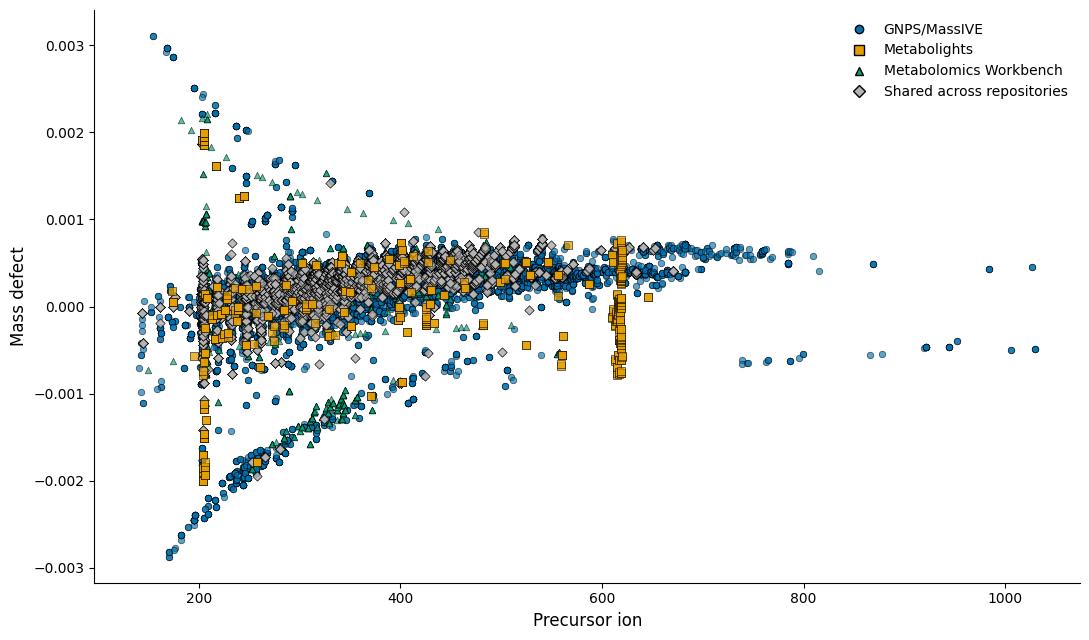

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib as mpl

# Embed fonts in vector exports (publisher-friendly)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# ===================== Read & prepare =====================
df = pd.read_csv(Path("summary_repositories_precmz4decimals.tsv"), sep="\t")

mass_carnitine = 162.1125
df["delta_mass"] = (df["precmz"] - mass_carnitine).round(2)

repo_counts = (
    df.groupby("delta_mass")["origin_repository"]
      .nunique()
      .reset_index(name="repo_count")
)
df = df.merge(repo_counts, on="delta_mass", how="left")

df["color_group"] = df.apply(
    lambda r: "Shared across repositories" if r["repo_count"] > 1 else r["origin_repository"],
    axis=1
)

df["delta_mass_defect"] = (df["delta_mass"] - df["delta_mass"].round()) / df["precmz"]

# ===================== Palettes & markers =====================
PALETTE = "okabe_ito"   # options: "okabe_ito" or "tol_bright"

okabe_ito = {
    "GNPS/MassIVE": "#0072B2",
    "Metabolights": "#E69F00",
    "Metabolomics Workbench": "#009E73",
    "Shared across repositories": "#b4b4b4"
}
tol_bright = {
    "GNPS/MassIVE": "#4477AA",
    "Metabolights": "#EE6677",
    "Metabolomics Workbench": "#228833",
    "Shared across repositories": "#b4b4b4"
}
palette = okabe_ito if PALETTE == "okabe_ito" else tol_bright

marker_map = {
    "GNPS/MassIVE": "o",
    "Metabolights": "s",
    "Metabolomics Workbench": "^",
    "Shared across repositories": "D"
}

# z-order: keep Metabolights on top
zmap = {
    "GNPS/MassIVE": 2,
    "Metabolomics Workbench": 2,
    "Shared across repositories": 2,
    "Metabolights": 5
}

legend_order = ["GNPS/MassIVE", "Metabolights", "Metabolomics Workbench", "Shared across repositories"]
present = [g for g in legend_order if g in df["color_group"].unique()]

# ===================== Plot =====================
fig, ax = plt.subplots(figsize=(11, 6.5))

for grp in present:
    dfg = df[df["color_group"] == grp]
    ax.scatter(
        dfg["precmz"], dfg["delta_mass_defect"],
        s=22 if grp != "Metabolights" else 26,    # slight emphasis
        alpha=0.65 if grp != "Metabolights" else 0.75,
        c=palette[grp], marker=marker_map[grp],
        edgecolors="black", linewidths=0.5,
        zorder=zmap.get(grp, 2),
        rasterized=(grp != "Metabolights")
    )

# Axis labels & style
ax.set_xlabel("Precursor ion", fontsize=12)
ax.set_ylabel("Mass defect", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --------- Legend via proxies (robust when no handles exist) ---------
legend_handles = [
    Line2D([0], [0], marker=marker_map[g], linestyle="None",
           markerfacecolor=palette[g], markeredgecolor="black",
           markersize=6 if g != "Metabolights" else 7.5, label=g)
    for g in present
]
ax.legend(legend_handles, [h.get_label() for h in legend_handles],
          loc="upper right", frameon=False, fontsize=10)

plt.tight_layout()

# ===== Save as high-quality PDF =====
plt.savefig("Supplementary_Figure_SX.pdf", format="pdf", bbox_inches="tight")

plt.show()
